In [12]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

plt.style.use('ggplot')

In [13]:
import pandas as pd

df = pd.read_csv("sales_data.csv")
df.head()

,Order_ID,Date,Product,Category,Region,Quantity,Price,Sales
0,1,2025-12-15,Mouse,Electronics,West,7,16295,114065
1,2,2025-08-03,Tablet,Electronics,West,5,6765,33825
2,3,2025-12-26,Tablet,Accessories,North,5,44631,223155
3,4,2025-07-11,Printer,Electronics,North,2,2933,5866
4,5,2025-08-24,Laptop,Electronics,East,6,6896,41376


In [14]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 1000
Columns : 8


In [15]:

df.describe()

,Order_ID,Quantity,Price,Sales
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,5.022000,26078.738000,130683.515000
std,288.819436,2.585382,14241.469141,104791.780388
min,1.000000,1.000000,509.000000,690.000000
25%,250.750000,3.000000,13983.750000,41488.000000
50%,500.500000,5.000000,26731.000000,103546.500000
75%,750.250000,7.000000,37862.500000,193631.250000
max,1000.000000,9.000000,49959.000000,440154.000000


In [16]:
df.isnull().sum()

Order_ID    0
Date        0
Product     0
Category    0
Region      0
Quantity    0
Price       0
Sales       0
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df['Date'] = pd.to_datetime(df['Date'])

In [19]:
df['Month'] = df['Date'].dt.month_name()

df['Year'] = df['Date'].dt.year

df['Quarter'] = df['Date'].dt.quarter

In [20]:
total_sales = df['Sales'].sum()

print(f"Total Sales : ₹{total_sales:,.0f}")

Total Sales : ₹130,683,515


In [21]:
total_orders = df['Order_ID'].nunique()

print("Total Orders :", total_orders)

Total Orders : 1000


In [22]:
total_quantity = df['Quantity'].sum()

print("Total Quantity Sold :", total_quantity)

Total Quantity Sold : 5022


In [23]:
avg_order_value = df['Sales'].mean()

print(f"Average Order Value : ₹{avg_order_value:,.2f}")

Average Order Value : ₹130,683.51


In [24]:
monthly_sales = df.groupby('Month')['Sales'].sum().reset_index()

In [25]:
month_order = [
    'January','February','March',
    'April','May','June',
    'July','August','September',
    'October','November','December'
]

monthly_sales['Month'] = pd.Categorical(
    monthly_sales['Month'],
    categories=month_order,
    ordered=True
)

monthly_sales = monthly_sales.sort_values('Month')

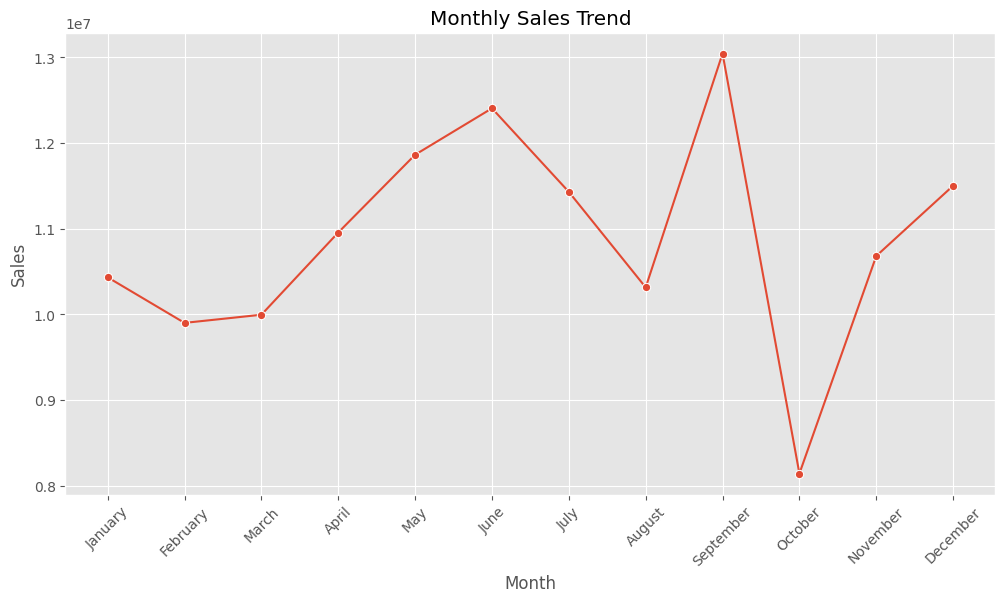

In [26]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=monthly_sales,
    x='Month',
    y='Sales',
    marker='o'
)

plt.title("Monthly Sales Trend")
plt.xticks(rotation=45)

plt.show()

In [27]:
region_sales = (
    df.groupby('Region')['Sales']
    .sum()
    .sort_values(ascending=False)
)

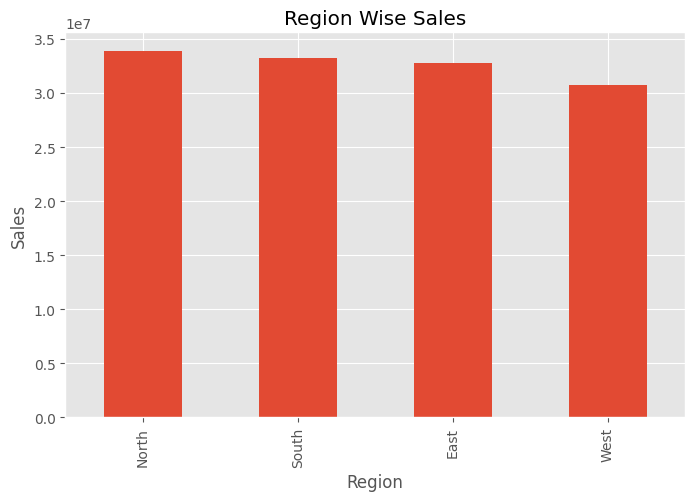

In [28]:
plt.figure(figsize=(8,5))

region_sales.plot(kind='bar')

plt.title("Region Wise Sales")

plt.ylabel("Sales")

plt.show()

In [29]:
category_sales = (
    df.groupby('Category')['Sales']
    .sum()
    .sort_values(ascending=False)
)

category_sales

Category
Electronics    67066666
Accessories    63616849
Name: Sales, dtype: int64

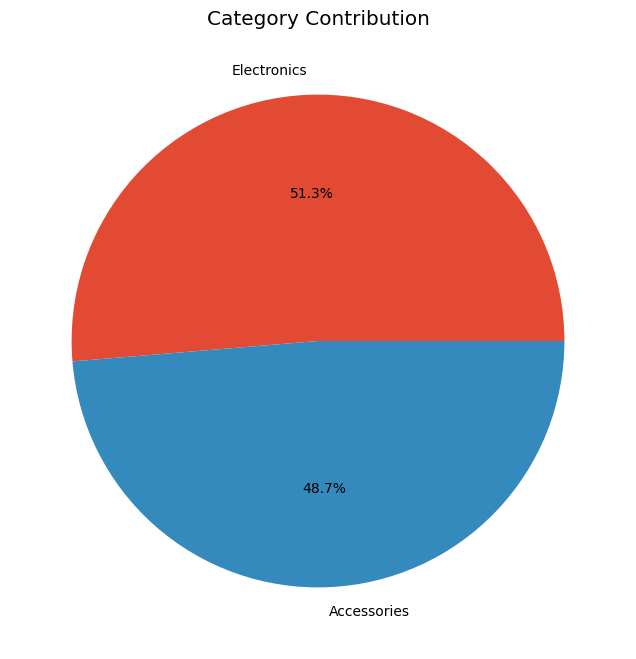

In [30]:
plt.figure(figsize=(8,8))

category_sales.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel("")

plt.title("Category Contribution")

plt.show()

In [31]:
top_products = (
    df.groupby('Product')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Product
Monitor     20887665
Mouse       20681552
Laptop      20386193
Printer     18515755
Keyboard    17250276
Tablet      16700871
Mobile      16261203
Name: Sales, dtype: int64

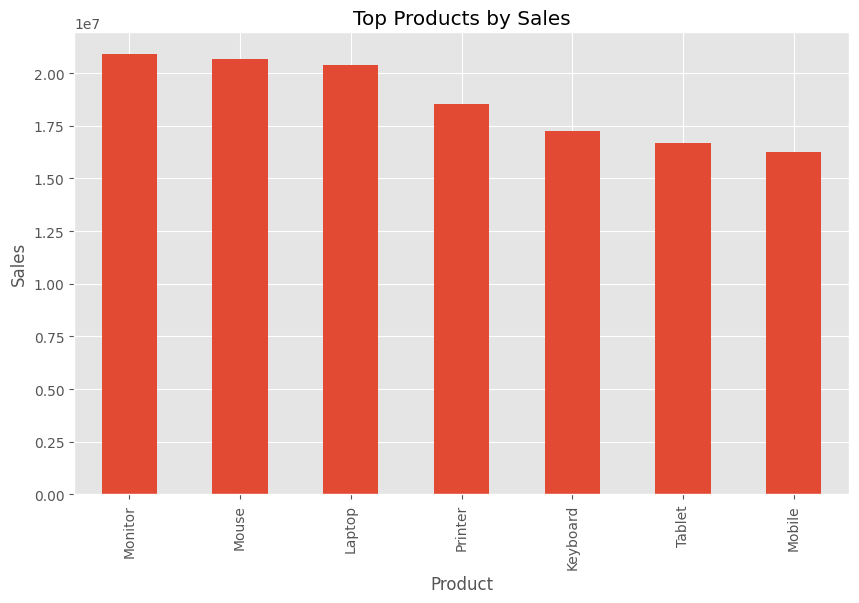

In [32]:
plt.figure(figsize=(10,6))

top_products.plot(kind='bar')

plt.title("Top Products by Sales")

plt.ylabel("Sales")

plt.show()

In [33]:
quantity_product = (
    df.groupby('Product')['Quantity']
    .sum()
    .sort_values(ascending=False)
)

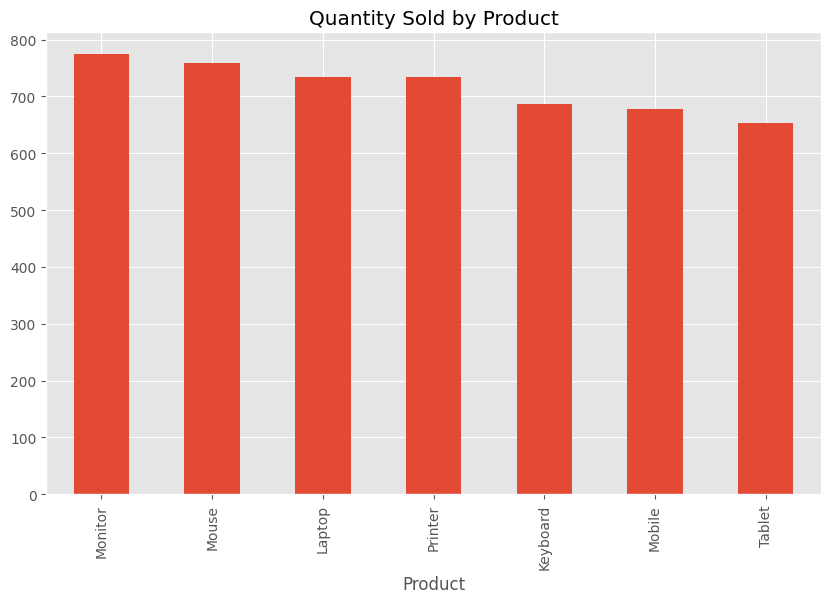

In [34]:
plt.figure(figsize=(10,6))

quantity_product.plot(kind='bar')

plt.title("Quantity Sold by Product")

plt.show()

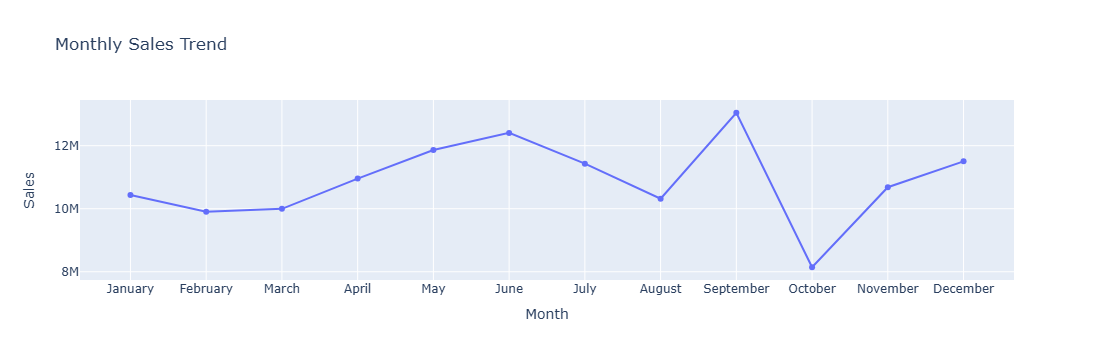

In [35]:
fig = px.line(
    monthly_sales,
    x="Month",
    y="Sales",
    markers=True,
    title="Monthly Sales Trend"
)

fig.show()

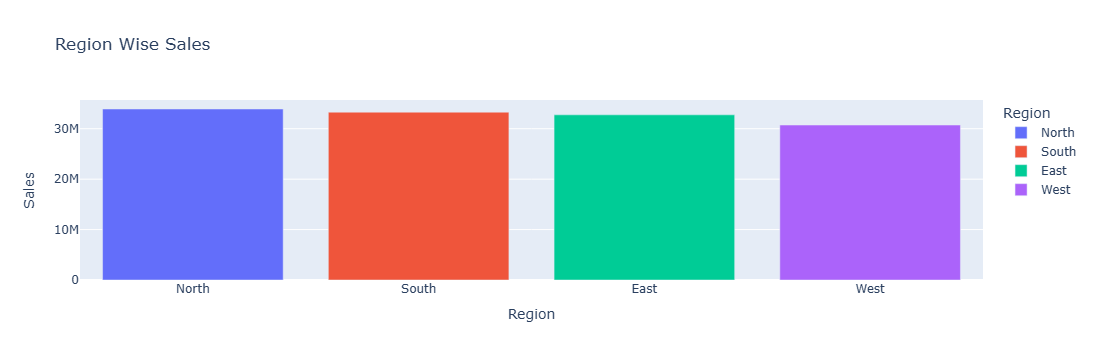

In [36]:
fig = px.bar(
    region_sales.reset_index(),
    x="Region",
    y="Sales",
    color="Region",
    title="Region Wise Sales"
)

fig.show()

In [37]:
best_region = region_sales.idxmax()

best_category = category_sales.idxmax()

best_product = top_products.idxmax()

print("Best Region :", best_region)

print("Best Category :", best_category)

print("Best Product :", best_product)

Best Region : North
Best Category : Electronics
Best Product : Monitor


In [38]:
print("Business Recommendations")
print("-"*40)

print("1. Focus marketing on best performing region.")

print("2. Increase stock of top selling products.")

print("3. Expand high revenue categories.")

print("4. Create offers during low sales months.")

print("5. Track monthly trends for future planning.")

Business Recommendations
----------------------------------------
1. Focus marketing on best performing region.
2. Increase stock of top selling products.
3. Expand high revenue categories.
4. Create offers during low sales months.
5. Track monthly trends for future planning.
